# ***`Training your Custom Datasets with YOLOv11`***

In [1]:
!nvidia-smi

Tue Sep  1 07:26:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

- ***Installing Ultralytics***

In [2]:
!pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.137 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.3/112.6 GB disk)


- ***Dataset Preparation***
- ***[Dataset LINK](https://universe.roboflow.com/roboflow-58fyf/rock-paper-scissors-sxsw)***

- ***Download the Dataset in YOLOv11 format from Roboflow Universe***

- ***`(Optional) Upload the dataset in Google Drive`***

In [3]:
!pip install roboflow

In [4]:
from google.colab import userdata
api_key = userdata.get("api_key")
from roboflow import Roboflow
rf = Roboflow(api_key=api_key)
project = rf.workspace("roboflow-58fyf").project("rock-paper-scissors-sxsw")
version = project.version(14)
dataset = version.download("yolov11")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to rock-paper-scissors-14 in yolov11:: 100%|██████████| 14682/14682 [00:04<00:00, 3433.26it/s] 


In [5]:
!pwd

/content


In [6]:
%cd /content/rock-paper-scissors-14

/content/rock-paper-scissors-14


In [7]:
!pwd

/content/rock-paper-scissors-14


- ***Using the Command Line Interface***

In [8]:
!cat /content/rock-paper-scissors-14/data.yaml

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 3
names: ['Paper', 'Rock', 'Scissors']

roboflow:
  workspace: roboflow-58fyf
  project: rock-paper-scissors-sxsw
  version: 14
  license: Private
  url: https://universe.roboflow.com/roboflow-58fyf/rock-paper-scissors-sxsw/dataset/14

- ***Starting the Training Procedure***

In [9]:
# Train YOLO11n on Rock Paper Scissors Dataset for 25 epochs for better results
!yolo train model=yolo11n.pt data="/content/rock-paper-scissors-14/data.yaml" epochs=10 imgsz=640

Ultralytics 8.4.137 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/rock-paper-scissors-14/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=Fa

- ***Validating the Trained Model***

In [11]:
# Validate Trained Model on Validation Set
!yolo val model='/content/rock-paper-scissors-14/runs/detect/train/weights/best.pt' data='/content/rock-paper-scissors-14/data.yaml'

Ultralytics 8.4.137 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,737 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1499.8±657.0 MB/s, size: 29.5 KB)
val: Scanning /content/rock-paper-scissors-14/valid/labels.cache... 576 images, 238 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 576/576 105.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 36/36 5.5it/s 6.5s
                   all        576        400      0.927        0.9      0.945      0.741
                 Paper        132        139      0.915      0.906      0.948      0.741
                  Rock        121        141      0.935       0.92      0.947      0.739
              Scissors        116        120      0.932      0.875       0.94      0.743
Speed: 1.8ms preprocess, 3.9ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to /content/rock-pap

- ***Inferencing with our trained Model***

In [12]:
# Visualize the Predicted image function
import cv2
from google.colab.patches import cv2_imshow

def img_show(img_pth):
  """
    Function to display an image using OpenCV in Google Colab.

    Parameters:
    - image_path (str): Path to the image file.
  """
  img = cv2.imread(img_pth)
  if img is None:
    print("Error: Image not found!")
    return

  cv2_imshow(img)

In [13]:
# Inferencing with our trained model
!yolo predict model='/content/rock-paper-scissors-14/runs/detect/train/weights/best.pt' source='/content/rock-paper-scissors-14/valid/images/IMG_7043_MOV-153_jpg.rf.912568d728316b8e4f2d06c0dfb3e92a.jpg'

Ultralytics 8.4.137 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,737 parameters, 0 gradients, 6.4 GFLOPs

image 1/1 /content/rock-paper-scissors-14/valid/images/IMG_7043_MOV-153_jpg.rf.912568d728316b8e4f2d06c0dfb3e92a.jpg: 640x640 1 Paper, 8.5ms
Speed: 38.1ms preprocess, 8.5ms inference, 18.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/rock-paper-scissors-14/runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


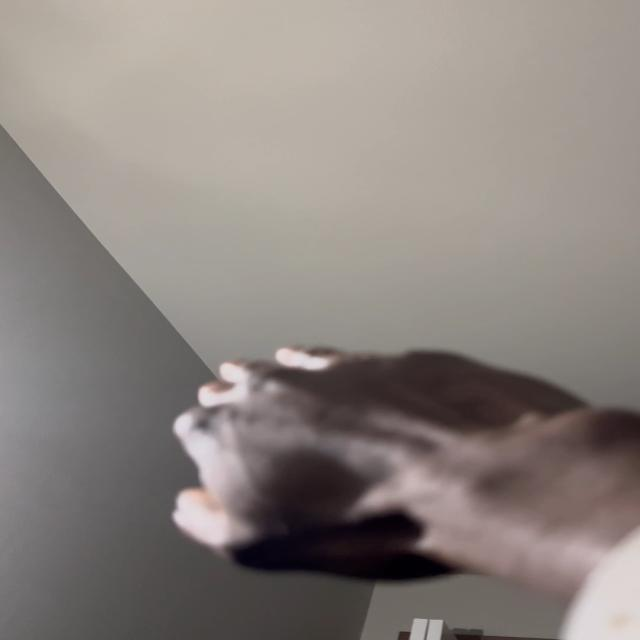

In [14]:
img_show('/content/rock-paper-scissors-14/valid/images/IMG_7043_MOV-153_jpg.rf.912568d728316b8e4f2d06c0dfb3e92a.jpg')

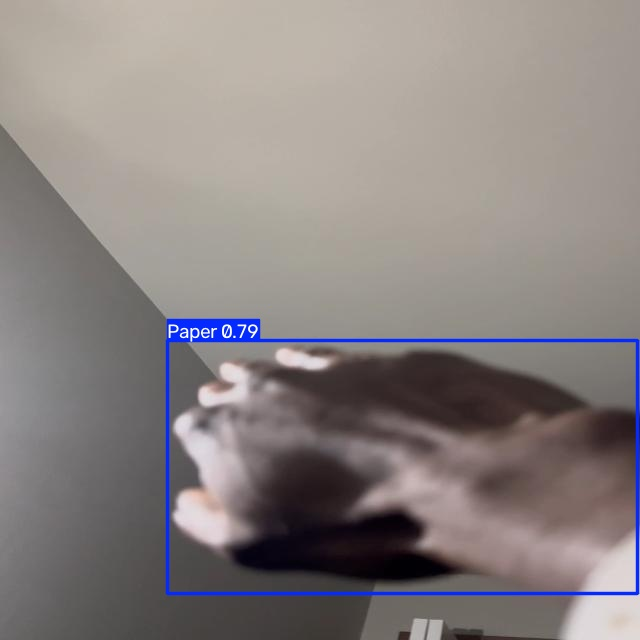

In [15]:
img_show('/content/rock-paper-scissors-14/runs/detect/predict/IMG_7043_MOV-153_jpg.rf.912568d728316b8e4f2d06c0dfb3e92a.jpg')

##  Export

Export a YOLO11 model to any supported format below with the `format` argument, i.e. `format=onnx`. See [YOLO11 Export Docs](https://docs.ultralytics.com/modes/export/) for more information.

- 💡 ProTip: Export to [ONNX](https://docs.ultralytics.com/integrations/onnx/) or [OpenVINO](https://docs.ultralytics.com/integrations/openvino/) for up to 3x CPU speedup.  
- 💡 ProTip: Export to [TensorRT](https://docs.ultralytics.com/integrations/tensorrt/) for up to 5x GPU speedup.

| Format                                                                   | `format` Argument | Model                     | Metadata | Arguments                                                            |
|--------------------------------------------------------------------------|-------------------|---------------------------|----------|----------------------------------------------------------------------|
| [PyTorch](https://pytorch.org/)                                          | -                 | `yolo11n.pt`              | ✅        | -                                                                    |
| [TorchScript](https://docs.ultralytics.com/integrations/torchscript)     | `torchscript`     | `yolo11n.torchscript`     | ✅        | `imgsz`, `optimize`, `batch`                                         |
| [ONNX](https://docs.ultralytics.com/integrations/onnx)                   | `onnx`            | `yolo11n.onnx`            | ✅        | `imgsz`, `half`, `dynamic`, `simplify`, `opset`, `batch`             |
| [OpenVINO](https://docs.ultralytics.com/integrations/openvino)           | `openvino`        | `yolo11n_openvino_model/` | ✅        | `imgsz`, `half`, `dynamic`, `int8`, `batch`, `data`                  |
| [TensorRT](https://docs.ultralytics.com/integrations/tensorrt)           | `engine`          | `yolo11n.engine`          | ✅        | `imgsz`, `half`, `dynamic`, `simplify`, `workspace`, `int8`, `batch`, `data` |
| [CoreML](https://docs.ultralytics.com/integrations/coreml)               | `coreml`          | `yolo11n.mlpackage`       | ✅        | `imgsz`, `half`, `int8`, `nms`, `batch`                              |
| [TF SavedModel](https://docs.ultralytics.com/integrations/tf-savedmodel) | `saved_model`     | `yolo11n_saved_model/`    | ✅        | `imgsz`, `keras`, `int8`, `batch`                                    |
| [TF GraphDef](https://docs.ultralytics.com/integrations/tf-graphdef)     | `pb`              | `yolo11n.pb`              | ❌        | `imgsz`, `batch`                                                     |
| [TF Lite](https://docs.ultralytics.com/integrations/tflite)              | `tflite`          | `yolo11n.tflite`          | ✅        | `imgsz`, `half`, `int8`, `batch`, `data`                             |
| [TF Edge TPU](https://docs.ultralytics.com/integrations/edge-tpu)        | `edgetpu`         | `yolo11n_edgetpu.tflite`  | ✅        | `imgsz`                                                              |
| [TF.js](https://docs.ultralytics.com/integrations/tfjs)                  | `tfjs`            | `yolo11n_web_model/`      | ✅        | `imgsz`, `half`, `int8`, `batch`                                     |
| [PaddlePaddle](https://docs.ultralytics.com/integrations/paddlepaddle)   | `paddle`          | `yolo11n_paddle_model/`   | ✅        | `imgsz`, `batch`                                                     |
| [MNN](https://docs.ultralytics.com/integrations/mnn)                     | `mnn`             | `yolo11n.mnn`             | ✅        | `imgsz`, `batch`, `int8`, `half`                                     |
| [NCNN](https://docs.ultralytics.com/integrations/ncnn)                   | `ncnn`            | `yolo11n_ncnn_model/`     | ✅        | `imgsz`, `half`, `batch`                                             |
| [IMX500](https://docs.ultralytics.com/integrations/sony-imx500)          | `imx`             | `yolov8n_imx_model/`      | ✅        | `imgsz`, `int8`, `data`                                              |
| [RKNN](https://docs.ultralytics.com/integrations/rockchip-rknn)          | `rknn`            | `yolo11n_rknn_model/`     | ✅        | `imgsz`, `batch`, `name`   

- ***Exporting in TensorRT for faster Inferencing Speeds on GPU***

In [16]:
!yolo export model=yolo11n.pt format=engine

WARNING ⚠️ TensorRT requires GPU export, automatically assigning device=0
Ultralytics 8.4.137 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino
YOLO11n summary (fused): 100 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs

PyTorch: starting from 'yolo11n.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (5.4 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime-gpu', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 12 packages in 302ms
Prepared 4 packages in 5.44s
Installed 4 packages in 250ms
 + colorama==0.4.6
 + onnx==1.22.0
 + onnxruntime-gpu==1.29.0
 + onnxslim==0.1.96

requirements: AutoUpdate success ✅ 6.5s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting expor

- ***PYTHON USAGE***

In [17]:
from ultralytics import YOLO

# Load our pretrained model
model = YOLO("yolo11n.pt")

# use the model
results = model.train(data='/content/rock-paper-scissors-14/data.yaml',epochs=1)
# train the model
#results = model.val()  # evaluate model performance on the validation set
#results = model('/content/drive/MyDrive/Yolo_Datasets/train/images/0001_png.rf.5e009a9ec5fbf7a8e856ba7f413996af.jpg')  # predict on an image
#results = model.export(format='onnx')  # export the model to ONNX format
#results = model.export(format='engine')

Ultralytics 8.4.137 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/rock-paper-scissors-14/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=F

In [18]:
from ultralytics import YOLO

model1 = YOLO('/content/rock-paper-scissors-14/runs/detect/train-2/weights/best.pt')

results=model1('/content/rock-paper-scissors-14/valid/images/0252_png.rf.3b1e7f3120a0c568624b7f25d9b7c366.jpg')


image 1/1 /content/rock-paper-scissors-14/valid/images/0252_png.rf.3b1e7f3120a0c568624b7f25d9b7c366.jpg: 640x640 (no detections), 8.9ms
Speed: 1.3ms preprocess, 8.9ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)


In [19]:
results

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 depth: None
 keypoints: None
 masks: None
 names: {0: 'Paper', 1: 'Rock', 2: 'Scissors'}
 obb: None
 orig_img: array([[[154, 170, 193],
         [154, 170, 193],
         [154, 170, 193],
         ...,
         [176, 154, 189],
         [176, 154, 189],
         [176, 154, 189]],
 
        [[154, 170, 193],
         [154, 170, 193],
         [154, 170, 193],
         ...,
         [176, 154, 189],
         [176, 154, 189],
         [176, 154, 189]],
 
        [[154, 170, 193],
         [154, 170, 193],
         [154, 170, 193],
         ...,
         [176, 154, 189],
         [176, 154, 189],
         [176, 154, 189]],
 
        ...,
 
        [[151, 178, 199],
         [151, 178, 199],
         [151, 178, 199],
         ...,
         [185, 208, 223],
         [186, 209, 224],
         [188, 211, 226]],
 
        [[151, 178, 199],
         [151, 178, 199],
         [151, 178, 

In [20]:
result = model1('/content/rock-paper-scissors-14/valid/images/20220216_222117_jpg.rf.d740fefce5785e5cf171ff7c09e983c1.jpg')


image 1/1 /content/rock-paper-scissors-14/valid/images/20220216_222117_jpg.rf.d740fefce5785e5cf171ff7c09e983c1.jpg: 640x640 (no detections), 11.1ms
Speed: 1.8ms preprocess, 11.1ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)
